# Name : Sharon Elango 
# Batch : 3
# Roll no : 62 
# EXP-4 : Classification Using Logistic Regression, Decision Tree, and k-Nearest Neighbors

In [23]:
import numpy as np 
import matplotlib.pyplot as plt 

from sklearn.datasets import make_moons 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, confusion_matrix 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

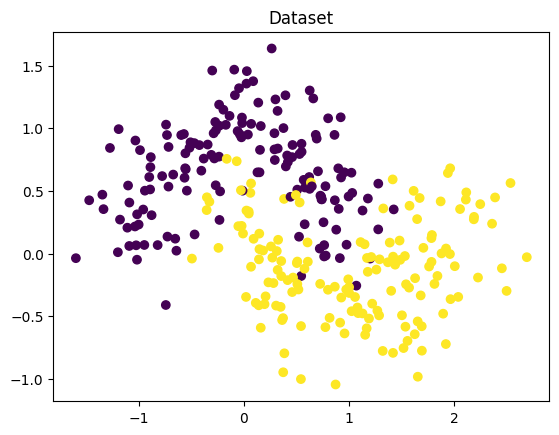

In [24]:
#============================================================
#Step-1 : Create Datatset (2D for visualization)
#============================================================

x,y = make_moons (n_samples=300, noise=0.25, random_state=42)

plt.scatter(x[:,0], x[:,1], c=y)
plt.title("Dataset")
plt.show()

In [25]:
#=================================================================
#Step-2 : Train-test split 
#=================================================================

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.3,random_state=0)

In [26]:
#=================================================================
#Step-3 : Scaling (important fort LR and KNN)
#=================================================================

scaler = StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [28]:
#==================================================================
#Step-4 : Models
#==================================================================

from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()
lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(x_test_scaled)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8777777777777778
Confusion Matrix:
 [[34  5]
 [ 6 45]]


In [30]:
from sklearn.tree import DecisionTreeClassifier 
dt = DecisionTreeClassifier(max_depth=4)
dt.fit(x_train_scaled, y_train)
y_pred_dt = dt.predict(x_test_scaled)
print("Decision_Tree")
print("Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_lr))

Decision_Tree
Accuracy: 0.8777777777777778
Confusion Matrix:
 [[34  5]
 [ 6 45]]


In [48]:
KNN = KNeighborsClassifier(n_neighbors=7)
KNN.fit(x_train_scaled, y_train)
y_pred_knn = KNN.predict(x_test_scaled)
print("Decision Tree")
print("Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred_lr))

Decision Tree
Accuracy: 0.8777777777777778
Confusion Matrix:
 [[34  5]
 [ 6 45]]


In [57]:
def plot_boundary(model, scaled, title):
    h=0.02
    x_min, x_max = x[:,0].min()-1, x[:,0].max()+1
    y_min, y_max = x[:,0].min()-1, x[:,0].max()+1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(x_min, x_max, h))

    grid = np.c_[(xx.ravel(), yy.ravel())]
    if scaled:
        grid = scaler.transform(grid)

    z=model.predict(grid)
    z = z.reshape(xx.shape)

    plt.contourf(xx, yy, z, alpha=0.8)
    plt.scatter(x[:,0], x[:,1], c=y, edgecolors='k', marker='o')
    plt.title(title)
    plt.show()

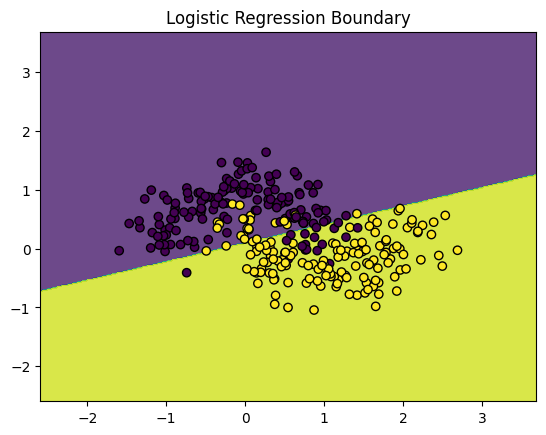

In [58]:
 plot_boundary(lr, True, "Logistic Regression Boundary")

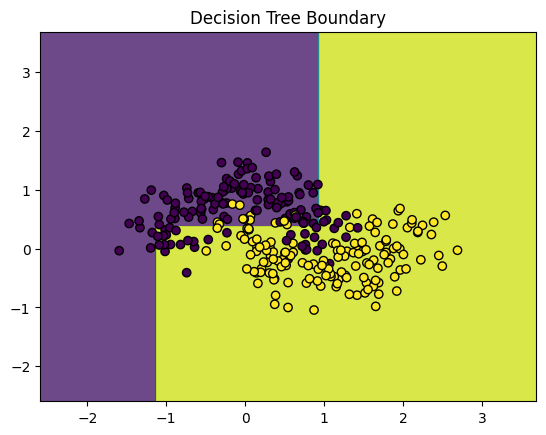

In [59]:
plot_boundary(dt, False, "Decision Tree Boundary")

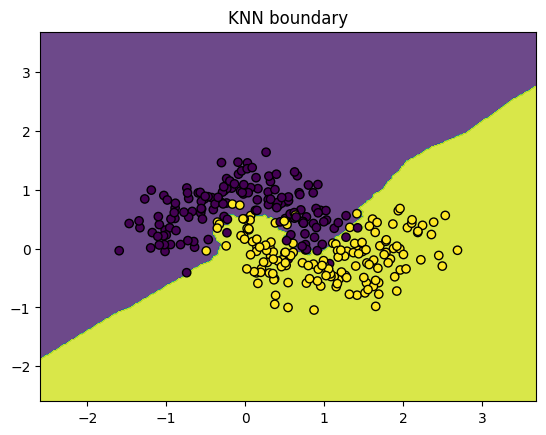

In [60]:
plot_boundary(KNN, True, "KNN boundary")